In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
import numpy as np

In [74]:
df = pd.read_csv("dados/processed/vendas_tratado.csv")

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_venda        150 non-null    int64  
 1   data_venda      146 non-null    object 
 2   cliente         150 non-null    object 
 3   produto         150 non-null    object 
 4   categoria       150 non-null    object 
 5   regiao          150 non-null    object 
 6   quantidade      150 non-null    float64
 7   preco_unitario  150 non-null    float64
 8   valor_total     150 non-null    float64
dtypes: float64(3), int64(1), object(5)
memory usage: 10.7+ KB


In [76]:
df['data_venda'] = pd.to_datetime(df['data_venda'], errors='coerce')

In [77]:
# Total mensal
df_mes = df.groupby(df['data_venda'].dt.to_period('M'))['valor_total'].sum().reset_index(name='total_mensal')

# Total trimestral
df_trimestre = df.groupby(df['data_venda'].dt.to_period('Q'))['valor_total'].sum().reset_index(name='total_trimestral')

# Total Geral
total_geral = df['valor_total'].sum()

# Exibindo os resultados
print(f"Faturamento Total do Período: R$ {total_geral:,.2f}\n")
display(df_mes, df_trimestre)

Faturamento Total do Período: R$ 1,273,130.00



,data_venda,total_mensal
0,2024-01,109690.0
1,2024-02,81760.0
2,2024-03,48140.0
3,2024-04,119500.0
4,2024-05,156770.0
5,2024-06,173540.0
6,2024-07,100780.0
7,2024-08,86430.0
8,2024-09,19790.0
9,2024-10,89750.0


,data_venda,total_trimestral
0,2024Q1,239590.0
1,2024Q2,449810.0
2,2024Q3,207000.0
3,2024Q4,331750.0


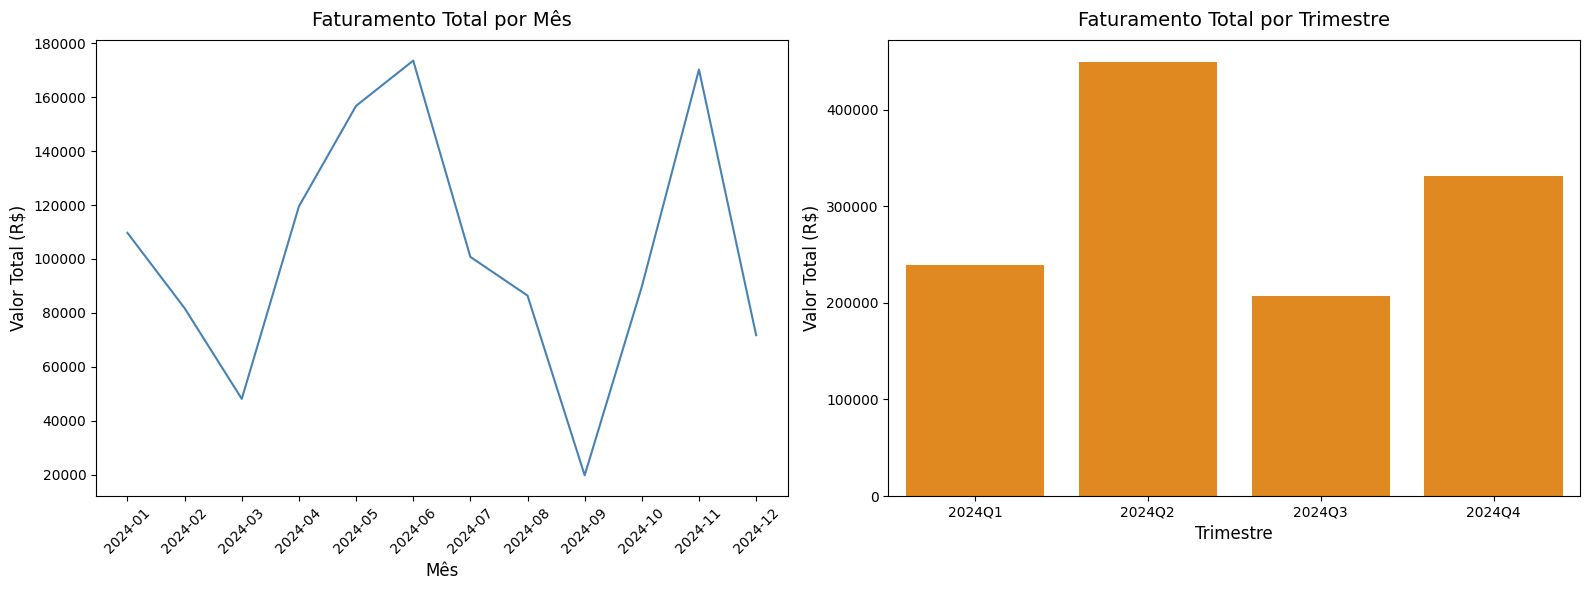

In [78]:
# Gráficos Lucro/Periodo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Faturamento Mensal
sns.lineplot(
    data=df_mes, 
    x=df_mes['data_venda'].astype(str), 
    y='total_mensal', 
    ax=axes[0], 
    color='steelblue')

axes[0].set_title('Faturamento Total por Mês', fontsize=14, pad=10)
axes[0].set_xlabel('Mês', fontsize=12)
axes[0].set_ylabel('Valor Total (R$)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45) # Inclina os meses para não encavalarem

# Gráfico 2: Faturamento trimestral
sns.barplot(
    data=df_trimestre, 
    x=df_trimestre.columns[0],
    y='total_trimestral', 
    ax=axes[1], 
    color='darkorange')

axes[1].set_title('Faturamento Total por Trimestre', fontsize=14, pad=10)
axes[1].set_xlabel('Trimestre', fontsize=12)
axes[1].set_ylabel('Valor Total (R$)', fontsize=12)

# Ajusta as margens e exibe
plt.tight_layout()
plt.show()

,categoria,valor_total,quantidade
1,Computadores,640750.0,268.5
0,Celulares,584600.0,291.0
2,Periféricos,47780.0,253.0


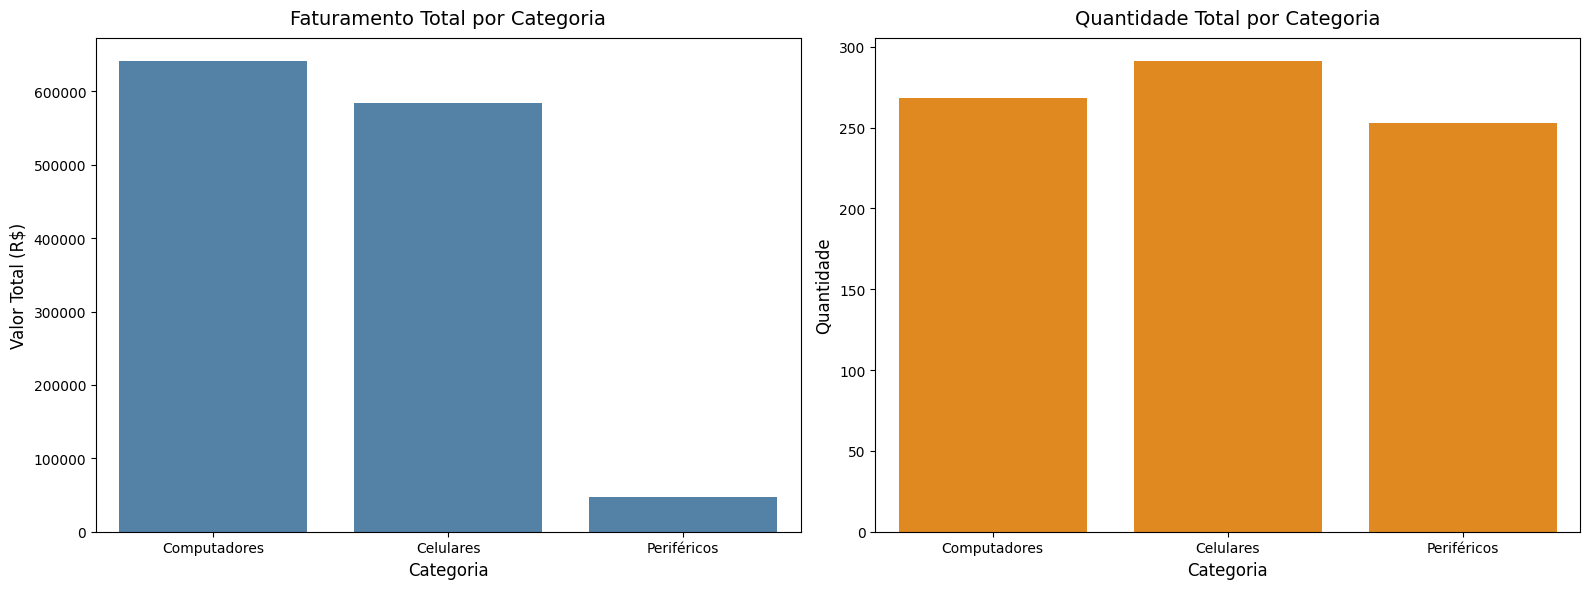

In [79]:
df_categoria = df.groupby('categoria')[['valor_total', 'quantidade']].sum().reset_index()
df_categoria = df_categoria.sort_values(by='valor_total', ascending=False)
display(df_categoria)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Categoria / Valor Bruto
sns.barplot(
    data=df_categoria, 
    x='categoria',          
    y='valor_total', 
    ax=axes[0],                
    color='steelblue'          
)
axes[0].set_title('Faturamento Total por Categoria', fontsize=14, pad=10)
axes[0].set_xlabel('Categoria', fontsize=12)
axes[0].set_ylabel('Valor Total (R$)', fontsize=12)

# Gráfico 2: Categoria / Quantidade 
sns.barplot(
    data=df_categoria, 
    x='categoria',          
    y='quantidade',      
    ax=axes[1],                
    color='darkorange'         
)
axes[1].set_title('Quantidade Total por Categoria', fontsize=14, pad=10) 
axes[1].set_xlabel('Categoria', fontsize=12)
axes[1].set_ylabel('Quantidade', fontsize=12)

plt.tight_layout()
plt.show()

,produto,valor_total,quantidade
2,Notebook,484750.0,138.5
3,Smartphone,334400.0,152.0
4,Tablet,250200.0,139.0
0,Monitor,156000.0,130.0
5,Teclado,33500.0,134.0
1,Mouse,14280.0,119.0


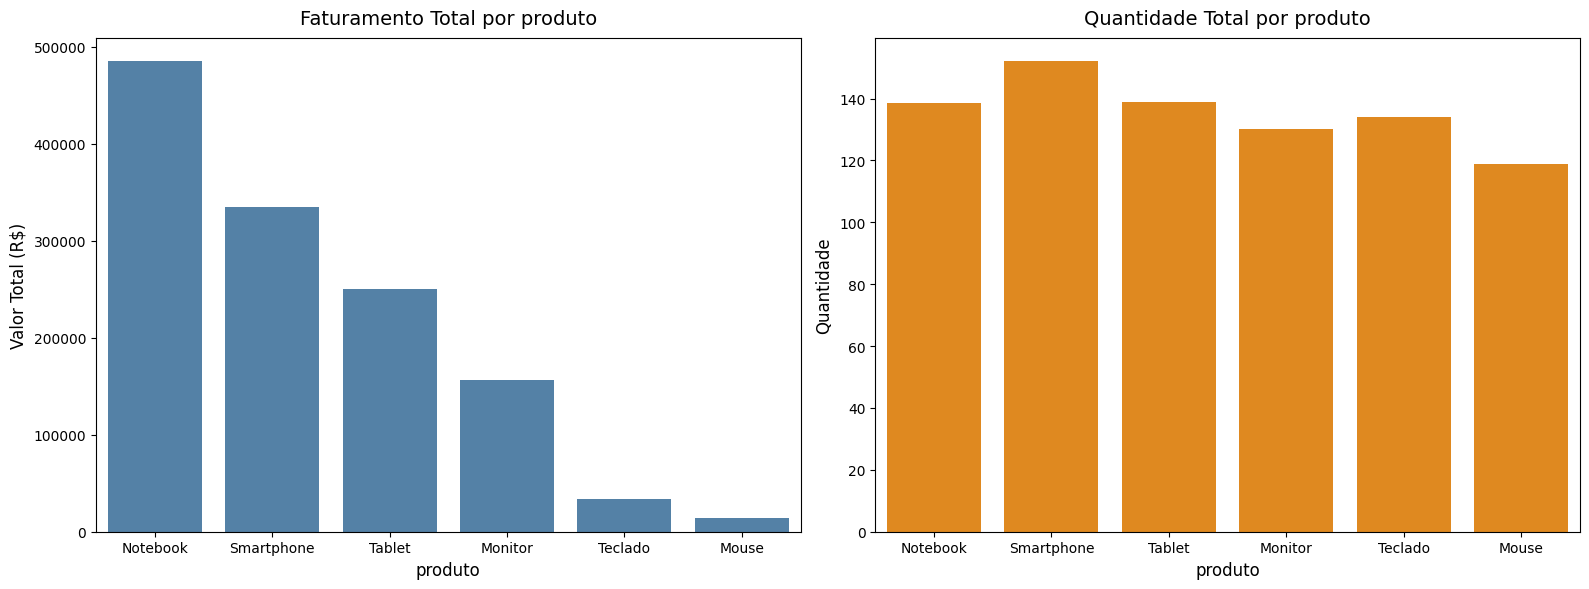

In [80]:
df_produto = df.groupby('produto')[['valor_total', 'quantidade']].sum().reset_index()
df_produto = df_produto.sort_values(by='valor_total', ascending=False)
display(df_produto)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: produto / Valor Bruto
sns.barplot(
    data=df_produto, 
    x='produto',          
    y='valor_total', 
    ax=axes[0],                
    color='steelblue'          
)
axes[0].set_title('Faturamento Total por produto', fontsize=14, pad=10)
axes[0].set_xlabel('produto', fontsize=12)
axes[0].set_ylabel('Valor Total (R$)', fontsize=12)

# Gráfico 2: produto / Quantidade 
sns.barplot(
    data=df_produto, 
    x='produto',          
    y='quantidade',      
    ax=axes[1],                
    color='darkorange'         
)
axes[1].set_title('Quantidade Total por produto', fontsize=14, pad=10) 
axes[1].set_xlabel('produto', fontsize=12)
axes[1].set_ylabel('Quantidade', fontsize=12)

plt.tight_layout()
plt.show()

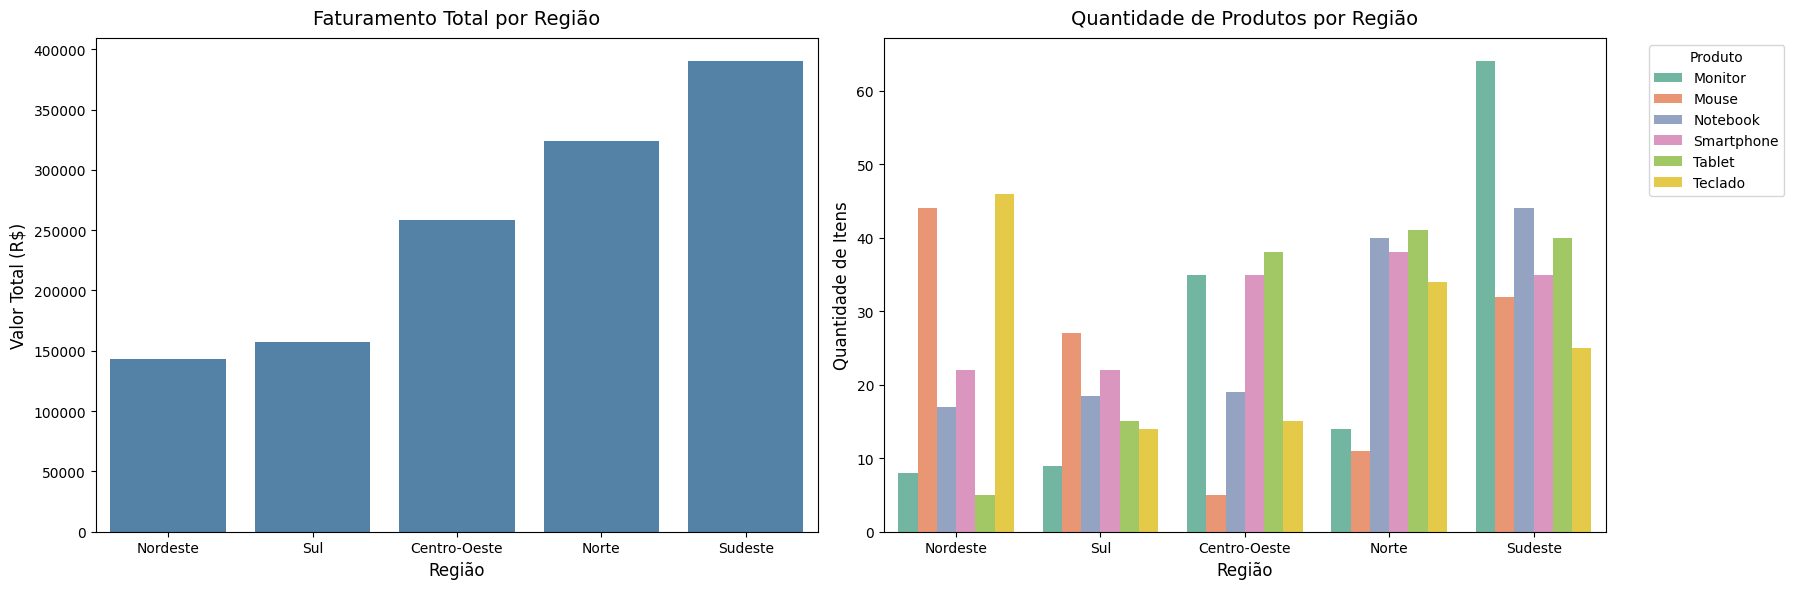

In [81]:
# df Região / Valor Bruto
df_faturamento_regiao = df.groupby('regiao')['valor_total'].sum().reset_index()
df_faturamento_regiao = df_faturamento_regiao.sort_values(by='valor_total', ascending=True)

# df quantidade de produtos vendido por região
df_qtd_regiao = df.groupby(['regiao', 'produto'])['quantidade'].sum().reset_index()
ordem_regioes = df_faturamento_regiao['regiao'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Lucro/Faturamento por Região 
sns.barplot(
    data=df_faturamento_regiao, 
    x='regiao',           
    y='valor_total', 
    ax=axes[0],                
    color='steelblue'          
)
axes[0].set_title('Faturamento Total por Região', fontsize=14, pad=10)
axes[0].set_xlabel('Região', fontsize=12)
axes[0].set_ylabel('Valor Total (R$)', fontsize=12)

# Gráfico 2: Quantidade de Produtos por Região 
sns.barplot(
    data=df_qtd_regiao,
    x='regiao',
    y='quantidade',
    hue='produto',
    order=ordem_regioes,
    ax=axes[1],
    palette='Set2')

axes[1].set_title('Quantidade de Produtos por Região', fontsize=14, pad=10) 
axes[1].set_xlabel('Região', fontsize=12)
axes[1].set_ylabel('Quantidade de Itens', fontsize=12)


axes[1].legend(title='Produto', bbox_to_anchor=(1.05, 1), loc='upper left') 

plt.tight_layout()
plt.show()

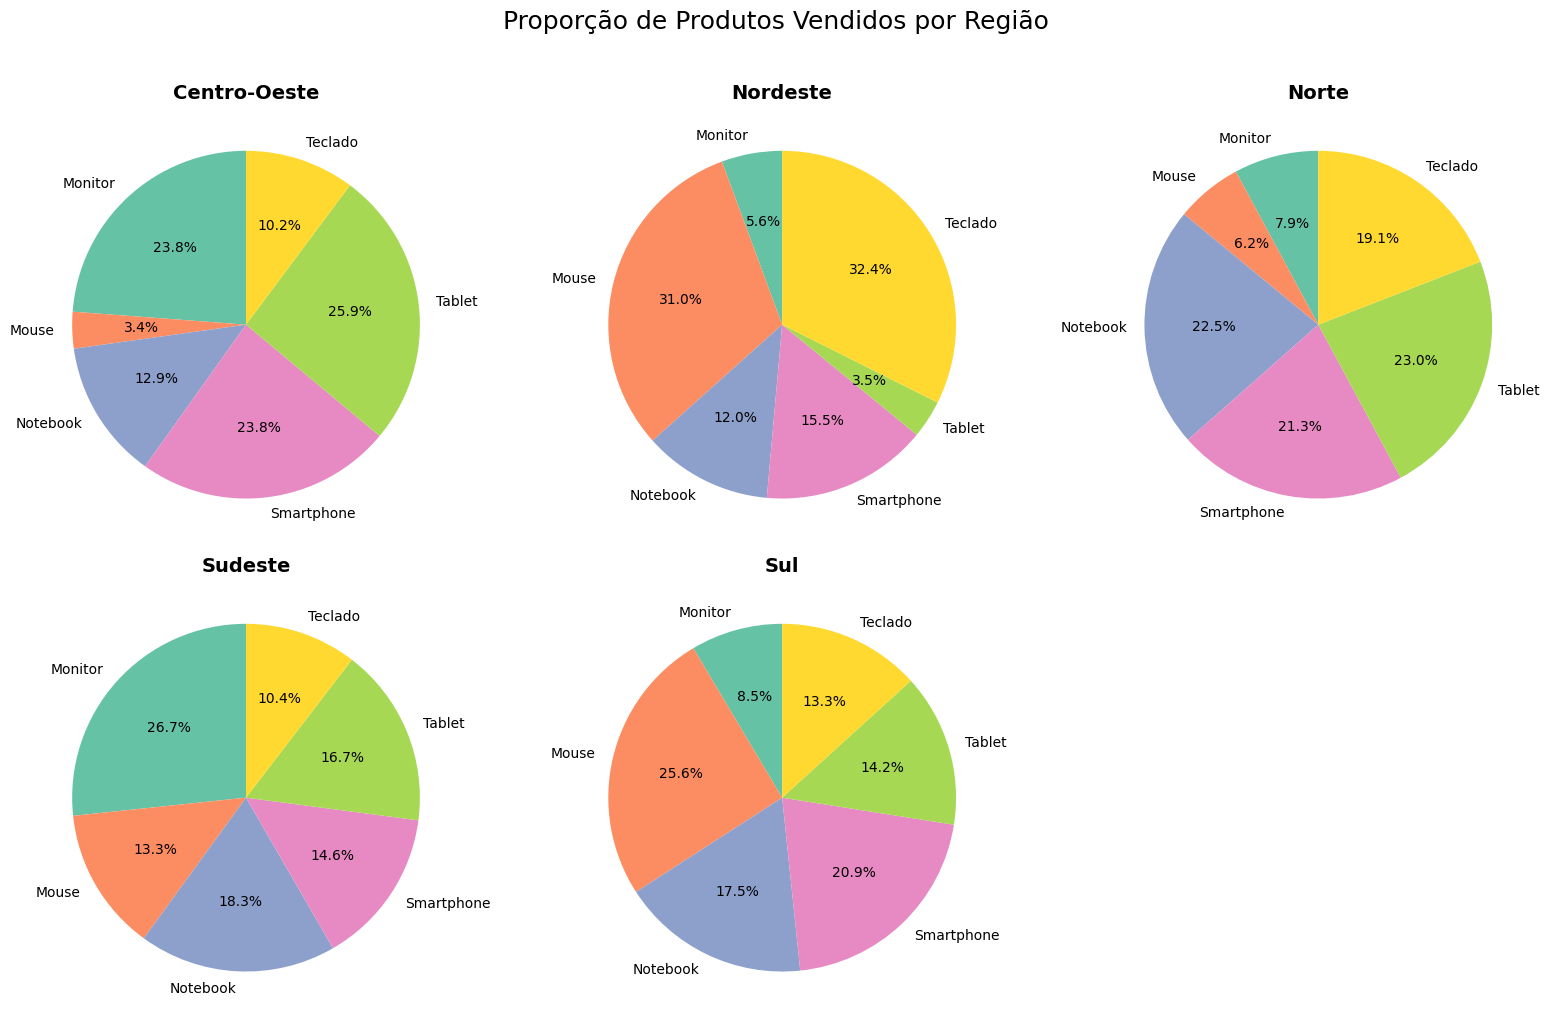

In [82]:
regioes = df_qtd_regiao['regiao'].unique()

# Define quantas linhas e colunas o painel terá (ex: 2 linhas, 3 colunas para caber 5 regiões)
colunas = 3
linhas = math.ceil(len(regioes) / colunas)

# Cria a figura e a grade de eixos (subplots)
fig, axes = plt.subplots(linhas, colunas, figsize=(16, 10))
axes = axes.flatten()
cores = sns.color_palette('Set2')

for i, regiao in enumerate(regioes):
    dados_regiao = df_qtd_regiao[df_qtd_regiao['regiao'] == regiao]
    axes[i].pie(
        dados_regiao['quantidade'], 
        labels=dados_regiao['produto'], 
        autopct='%1.1f%%',     
        startangle=90,        
        colors=cores)
    axes[i].set_title(regiao, fontsize=14, fontweight='bold')

for j in range(len(regioes), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Proporção de Produtos Vendidos por Região', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig(
    'faturamento_produtos.png', 
    dpi=300,                    
    bbox_inches='tight'       
)
plt.show()

--- Clientes Únicos por Região ---


,regiao,qtd_clientes
3,Sudeste,24
0,Centro-Oeste,23
2,Norte,21
1,Nordeste,18
4,Sul,15



--- Total Gasto por Cliente ---


,cliente,total_gasto
13,Cliente_014,79760.0
22,Cliente_023,76700.0
23,Cliente_024,72730.0
12,Cliente_013,72710.0
14,Cliente_015,71800.0
28,Cliente_029,66230.0
17,Cliente_018,65850.0
21,Cliente_022,60680.0
2,Cliente_003,59400.0
3,Cliente_004,58000.0


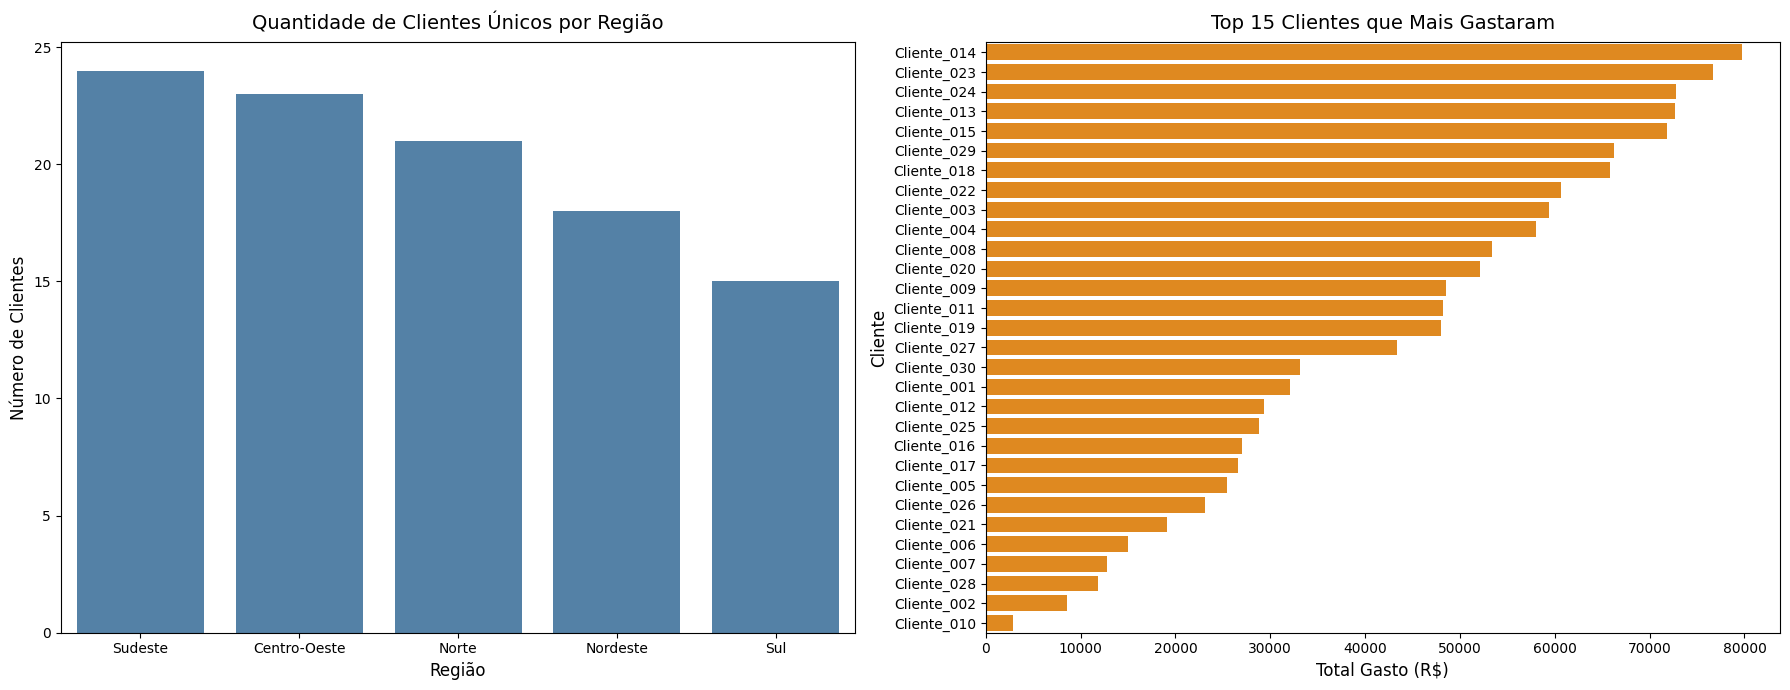

In [83]:
# df Região / Cliente
df_clientes_regiao = df.groupby('regiao')['cliente'].nunique().reset_index(name='qtd_clientes')
df_clientes_regiao = df_clientes_regiao.sort_values(by='qtd_clientes', ascending=False)

# df Cliente / Valor Bruto
df_gasto_cliente = df.groupby('cliente')['valor_total'].sum().reset_index(name='total_gasto')
df_gasto_cliente = df_gasto_cliente.sort_values(by='total_gasto', ascending=False)

print("--- Clientes Únicos por Região ---")
display(df_clientes_regiao)
print("\n--- Total Gasto por Cliente ---")
display(df_gasto_cliente)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Clientes por Região
sns.barplot(
    data=df_clientes_regiao,
    x='regiao',
    y='qtd_clientes',
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Quantidade de Clientes Únicos por Região', fontsize=14, pad=10)
axes[0].set_xlabel('Região', fontsize=12)
axes[0].set_ylabel('Número de Clientes', fontsize=12)

# Gráfico 2: Total Gasto por Cliente (Barras Horizontais)
sns.barplot(
    data=df_gasto_cliente,
    x='total_gasto',
    y='cliente',
    ax=axes[1],
    color='darkorange'
)
axes[1].set_title('Top 15 Clientes que Mais Gastaram', fontsize=14, pad=10)
axes[1].set_xlabel('Total Gasto (R$)', fontsize=12)
axes[1].set_ylabel('Cliente', fontsize=12)


plt.tight_layout()
plt.show()

In [84]:
#Visualizando distribuição dos dados
df_gasto_cliente.describe().round(2)

,total_gasto
count,30.00
mean,42437.67
std,22808.66
min,2880.00
25%,25767.50
50%,45705.00
75%,60360.00
max,79760.00


In [85]:
# Classificação clientes
limites = [-np.inf, 5000, 15000, np.inf]
rotulos = ['bronze', 'prata', 'ouro']

df_gasto_cliente['classificacao_cliente'] = pd.cut(
    df_gasto_cliente['total_gasto'], 
    bins=limites, 
    labels=rotulos,
    right=False 
)

display(df_gasto_cliente['classificacao_cliente'].value_counts())

classificacao_cliente
ouro      25
prata      4
bronze     1
Name: count, dtype: int64